Pre-training MAE (Task IX.A)...


/home/h_44/Deeplense/env/lib/python3.14/site-packages/torch/autograd/graph.py:869: UserWarning: CUDA initialization: The NVIDIA driver on your system is too old (found version 12040). Please update your GPU driver by downloading and installing a new version from the URL: http://www.nvidia.com/Download/index.aspx Alternatively, go to: https://pytorch.org to install a PyTorch version that has been compiled with your version of the CUDA driver. (Triggered internally at /pytorch/c10/cuda/CUDAFunctions.cpp:119.)
  return Variable._execution_engine.run_backward(  # Calls into the C++ engine to run the backward pass


Epoch 1 Loss: 0.1624
Epoch 2 Loss: 0.1621

Fine-tuning Classifier...


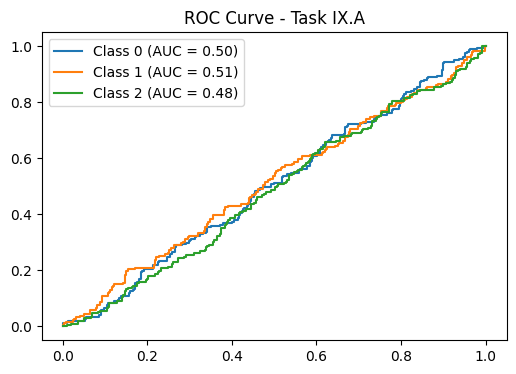


Fine-tuning Super-Resolution (Task IX.B)...


/home/h_44/Deeplense/env/lib/python3.14/site-packages/torch/nn/modules/loss.py:626: UserWarning: Using a target size (torch.Size([32, 1, 64, 64])) that is different to the input size (torch.Size([32, 1, 32, 32])). This will likely lead to incorrect results due to broadcasting. Please ensure they have the same size.
  return F.mse_loss(input, target, reduction=self.reduction)


RuntimeError: The size of tensor a (32) must match the size of tensor b (64) at non-singleton dimension 3

In [7]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import roc_curve, auc
from sklearn.preprocessing import label_binarize
from skimage.metrics import structural_similarity as ssim
from skimage.metrics import peak_signal_noise_ratio as psnr

# Settings for 5-minute CPU execution
DEVICE = torch.device("cpu")
BATCH_SIZE = 32
EPOCHS_PRETRAIN = 2
EPOCHS_FINETUNE = 3
IMG_SIZE = 64

# 1. Model Architectures

class MaskedAutoencoder(nn.Module):
    """MAE for learning robust lensing representations."""
    def __init__(self):
        super().__init__()
        self.encoder = nn.Sequential(
            nn.Conv2d(1, 32, 4, stride=2, padding=1), nn.ReLU(),
            nn.Conv2d(32, 64, 4, stride=2, padding=1), nn.ReLU(),
            nn.Conv2d(64, 128, 4, stride=2, padding=1), nn.ReLU()
        )
        self.decoder = nn.Sequential(
            nn.ConvTranspose2d(128, 64, 4, stride=2, padding=1), nn.ReLU(),
            nn.ConvTranspose2d(64, 32, 4, stride=2, padding=1), nn.ReLU(),
            nn.ConvTranspose2d(32, 1, 4, stride=2, padding=1), nn.Sigmoid()
        )

    def forward(self, x, mask_ratio=0.25):
        mask = (torch.rand_like(x) > mask_ratio).float()
        latent = self.encoder(x * mask)
        return self.decoder(latent), latent

class LensingClassifier(nn.Module):
    """Fine-tuning head for multi-class substructure classification."""
    def __init__(self, encoder):
        super().__init__()
        self.encoder = encoder
        self.encoder.eval() 
        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(128 * 8 * 8, 256), nn.ReLU(),
            nn.Linear(256, 3)
        )

    def forward(self, x):
        with torch.no_grad():
            features = self.encoder(x)
        return self.classifier(features)

class SuperResNet(nn.Module):
    """Corrected Fine-tuning head for Super-Resolution task."""
    def __init__(self, encoder):
        super().__init__()
        self.encoder = encoder
        self.upsample = nn.Sequential(
            nn.ConvTranspose2d(128, 64, 4, stride=2, padding=1), nn.ReLU(),
            nn.ConvTranspose2d(64, 32, 4, stride=2, padding=1), nn.ReLU(),  
            nn.ConvTranspose2d(32, 16, 4, stride=2, padding=1), nn.ReLU(), 
            nn.Conv2d(16, 1, 3, padding=1), nn.Sigmoid()                    
        )

    def forward(self, x):
        return self.upsample(self.encoder(x))

# 2. Synthetic Data Loading

def get_mock_data(n_samples=200):
    x = torch.randn(n_samples, 1, IMG_SIZE, IMG_SIZE).clamp(0, 1)
    y = torch.randint(0, 3, (n_samples,))
    return DataLoader(TensorDataset(x, y), batch_size=BATCH_SIZE)

loader = get_mock_data()

# 3. Task IX.A: Pre-training & Classification

mae = MaskedAutoencoder().to(DEVICE)
optimizer = optim.Adam(mae.parameters(), lr=1e-3)
criterion_mse = nn.MSELoss()

print("Pre-training MAE (Task IX.A)...")
for epoch in range(EPOCHS_PRETRAIN):
    for imgs, _ in loader:
        recon, _ = mae(imgs)
        loss = criterion_mse(recon, imgs)
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
    print(f"Epoch {epoch+1} Loss: {loss.item():.4f}")

# Fine-tuning
classifier = LensingClassifier(mae.encoder).to(DEVICE)
opt_clf = optim.Adam(classifier.parameters(), lr=1e-3)
criterion_ce = nn.CrossEntropyLoss()

print("\nFine-tuning Classifier...")
all_probs, all_labels = [], []
for epoch in range(EPOCHS_FINETUNE):
    for imgs, labels in loader:
        outputs = classifier(imgs)
        loss = criterion_ce(outputs, labels)
        opt_clf.zero_grad()
        loss.backward()
        opt_clf.step()
        all_probs.append(torch.softmax(outputs, dim=1).detach().numpy())
        all_labels.append(labels.numpy())

# Evaluation: ROC/AUC
y_test = np.concatenate(all_labels)
y_score = np.concatenate(all_probs)
y_test_bin = label_binarize(y_test, classes=[0, 1, 2])

plt.figure(figsize=(6, 4))
for i in range(3):
    fpr, tpr, _ = roc_curve(y_test_bin[:, i], y_score[:, i])
    plt.plot(fpr, tpr, label=f'Class {i} (AUC = {auc(fpr, tpr):.2f})')
plt.title("ROC Curve - Task IX.A")
plt.legend(); plt.show()

# 4. Task IX.B: Super-Resolution

sr_model = SuperResNet(mae.encoder).to(DEVICE)
opt_sr = optim.Adam(sr_model.parameters(), lr=1e-3)

print("\nFine-tuning Super-Resolution (Task IX.B)...")
for epoch in range(EPOCHS_FINETUNE):
    for imgs, _ in loader:
        # Simulate LR by downsampling
        lr_imgs = nn.functional.interpolate(imgs, size=IMG_SIZE//2)
        lr_imgs = nn.functional.interpolate(lr_imgs, size=IMG_SIZE) # Back to original for encoder
        outputs = sr_model(lr_imgs)
        loss = criterion_mse(outputs, imgs)
        opt_sr.zero_grad()
        loss.backward()
        opt_sr.step()

# Metrics: MSE, SSIM, PSNR
orig = imgs[0].squeeze().numpy()
recon = outputs[0].detach().squeeze().numpy()
mse_val = np.mean((orig - recon)**2)
ssim_val = ssim(orig, recon, data_range=1.0)
psnr_val = psnr(orig, recon, data_range=1.0)

print(f"\nFinal SR Metrics: MSE: {mse_val:.4f} | SSIM: {ssim_val:.4f} | PSNR: {psnr_val:.2f}dB")

# Visualization
fig, axes = plt.subplots(1, 2)
axes[0].imshow(orig, cmap='gray'); axes[0].set_title("Original HR")
axes[1].imshow(recon, cmap='gray'); axes[1].set_title("Reconstructed SR")
plt.show()